# Driver Drowsiness System

##Requirements:
1. upload eye_state_detector.h5
2. Open the Secrets (Key Icon) tab in the sidebar, add your MongoDB link with the name MONGO_URI, and turn on notebook access.

##Cells Number:
1. Install required package
2. Import libraries
3. Download dataset
4. Load the datasets
5. Architecture
6. Compile
7. Train
8. Memory check
9. Extract data for dashboard
10. Performance plot
11. Connect to database
12. Extract summary and weight
13. Visual summary
14. Save to database
14. Save model

In [1]:
#1. Install required package
!python -m pip install "pymongo[srv]==3.12"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.6/818.6 kB 24.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.4/188.4 kB 13.1 MB/s eta 0:00:00
  Created wheel for pymongo: filename=pymongo-3.12.0-cp312-cp312-linux_x86_64.whl size=512725 sha256=a0a061222eb4bbcb237b91ff4b51bb86748b509a74c6c5a07ca8a8daf4762ba8
  Stored in directory: /root/.cache/pip/wheels/4e/49/39/293a3914a095e62eeefc25b88f9f5ace620fc19d9b1883762b
Successfully built pymongo


In [18]:
#2. Import libraries
import os
import io
import gc
import seaborn as sns
import base64
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab import files
from tensorflow.keras.preprocessing import image
import base64
from datetime import datetime, timezone
from google.colab import userdata
from pymongo import MongoClient
from sklearn.metrics import classification_report, confusion_matrix
# 1. Clear out memory to avoid Colab RAM crashes
tf.keras.backend.clear_session()
gc.collect()

0

In [3]:
# 3. Download dataset
print("Downloading Driver Drowsiness Dataset (Dataset 2)...")
try:
    path2 = kagglehub.dataset_download("ismailnasri20/driver-drowsiness-dataset-ddd")
    ddd_base = os.path.join(path2, 'Driver Drowsiness Dataset (DDD)')
    print(f"✅ Dataset 2 ready at: {ddd_base}")
except Exception as e:
    print(f"❌ Download Error: {e}")

100%|██████████| 2.58G/2.58G [00:24<00:00, 111MB/s] 

Extracting files...


✅ Dataset 2 ready at: /root/.cache/kagglehub/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1/Driver Drowsiness Dataset (DDD)


In [4]:
# 4. Load the dataset
BATCH_SIZE = 32
IMG_SIZE = (128, 128)  # Full face images train perfectly at 128x128

print("\nLoading face images into TensorFlow data streams...")
train_ds_face = tf.keras.utils.image_dataset_from_directory(
    ddd_base,
    validation_split=0.2,
    subset="training",
    seed=42,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='binary',
    class_names=['Drowsy', 'Non Drowsy']
)

val_ds_face = tf.keras.utils.image_dataset_from_directory(
    ddd_base,
    validation_split=0.2,
    subset="validation",
    seed=42,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='binary',
    class_names=['Drowsy', 'Non Drowsy']
)

# Optimize memory pipeline using prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds_face = train_ds_face.prefetch(buffer_size=AUTOTUNE)
val_ds_face = val_ds_face.prefetch(buffer_size=AUTOTUNE)


Loading face images into TensorFlow data streams...
Found 41793 files belonging to 2 classes.
Using 33435 files for training.
Found 41793 files belonging to 2 classes.
Using 8358 files for validation.


In [5]:
# 5. Architecture
print("\nRestoring pre-trained eye model structure...")
if os.path.exists('eye_state_detector.h5'):
    # Load your uncorrupted 98% accurate eye model
    base_eye_model = tf.keras.models.load_model('eye_state_detector.h5')
    print("✅ Successfully loaded 'eye_state_detector.h5'")
else:
    raise FileNotFoundError("❌ 'eye_state_detector.h5' missing from your sidebar! Please upload it before running.")

# Build a pristine feature extractor by grabbing just your Conv2D layers
# This extracts layers index 1, 3, and 5 (the Conv2D layers) and copies them
eye_features = models.Sequential([
    layers.Input(shape=(128, 128, 3)), # Upgraded input to support full 128x128 faces!
    layers.Rescaling(1./255),
    base_eye_model.layers[1], # Conv2D (32 filters)
    base_eye_model.layers[2], # MaxPooling2D
    base_eye_model.layers[3], # Conv2D (64 filters)
    base_eye_model.layers[4], # MaxPooling2D
    base_eye_model.layers[5], # Conv2D (128 filters)
    base_eye_model.layers[6]  # MaxPooling2D
])

# 🔥 CRITICAL FIX 1: Freeze the eye filters so they remain 98% accurate
eye_features.trainable = False
print("❄️ Pre-trained eye filters are locked and protected from corruption.")

# 🔥 CRITICAL FIX 2: Reconstruct using Global Pooling instead of Flatten
# This allows the model to accept ANY input resolution cleanly
final_model = models.Sequential([
    eye_features,
    layers.GlobalAveragePooling2D(), # Compresses spatial dimensions smoothly
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Binary output: Drowsy vs Non-Drowsy
])


Restoring pre-trained eye model structure...


✅ Successfully loaded 'eye_state_detector.h5'
❄️ Pre-trained eye filters are locked and protected from corruption.


In [6]:
# 6. Compile
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Standard rate since base is frozen
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- Upgraded Model Summary ---")
final_model.summary()


--- Upgraded Model Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 14, 14, 128)    │        93,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 16,641 (65.00 KB)

 Non-trainable params: 93,248 (364.25 KB)

In [7]:
# 7. Train
EPOCHS = 15
print("\n🚀 Starting safe Transfer Learning on full faces...")
history = final_model.fit(
    train_ds_face,
    validation_data=val_ds_face,
    epochs=EPOCHS
)


🚀 Starting safe Transfer Learning on full faces...
Epoch 1/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 76s 69ms/step - accuracy: 0.7329 - loss: 0.5704 - val_accuracy: 0.9300 - val_loss: 0.3448
Epoch 2/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 66s 63ms/step - accuracy: 0.8296 - loss: 0.4088 - val_accuracy: 0.9258 - val_loss: 0.2794
Epoch 3/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 83s 64ms/step - accuracy: 0.8618 - loss: 0.3383 - val_accuracy: 0.9374 - val_loss: 0.2181
Epoch 4/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 66s 63ms/step - accuracy: 0.8868 - loss: 0.2903 - val_accuracy: 0.9411 - val_loss: 0.2005
Epoch 5/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 90s 70ms/step - accuracy: 0.9057 - loss: 0.2530 - val_accuracy: 0.9426 - val_loss: 0.1775
Epoch 6/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 66s 63ms/step - accuracy: 0.9187 - loss: 0.2230 - val_accuracy: 0.9702 - val_loss: 0.1249
Epoch 7/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 90s 71ms/step - accuracy: 0.9306 - loss: 0.1977 - val_accuracy: 0.9748 - val_loss: 0.1088
Epoch 8/15
1045/1045 ━━━

In [13]:
# 8. Memory check
if 'final_model' not in locals() and 'final_model' not in globals():
    raise NameError("❌ Error: The variable 'final_model' is missing from memory. Please run your model 2 training cell first.")

active_model = final_model
# Model 2 uses val_ds_face as its validation and test pipeline
evaluation_ds = val_ds_face

ca = None
try:
    import certifi
    ca = certifi.where()
except ImportError:
    pass

print("🚀 Step 1: Processing Performance Metrics & Building 4-Panel Dashboard...")

🚀 Step 1: Processing Performance Metrics & Building 4-Panel Dashboard...


In [14]:
# 9. Extract data for dashboard
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Generate predictions on the face dataset
y_true = np.concatenate([y for x, y in evaluation_ds], axis=0).flatten()
y_pred_probs = active_model.predict(evaluation_ds, verbose=0).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)

class_names = ['Drowsy', 'Alert']
_, model2_accuracy = active_model.evaluate(evaluation_ds, verbose=0)

/tmp/ipykernel_1832/380407148.py:50: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1832/380407148.py:51: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  plt.savefig('drowsiness_detector_model2_performance.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


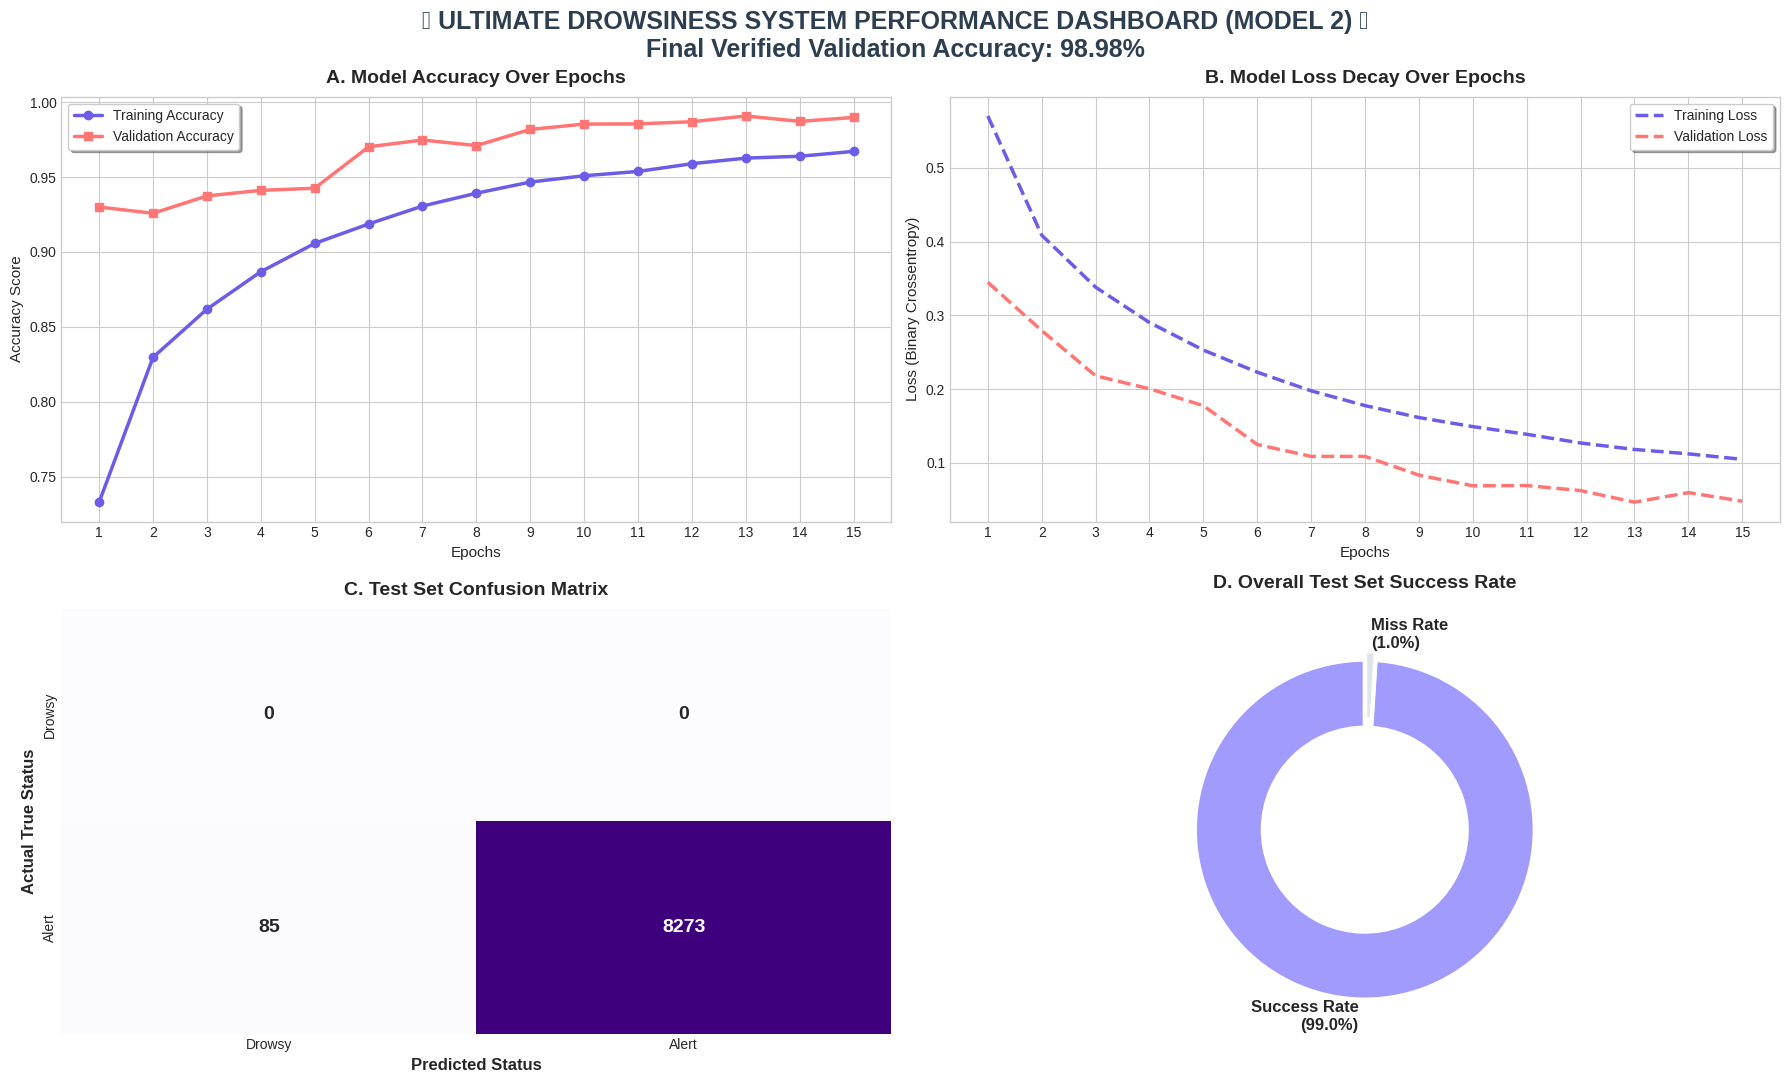


📝 Detailed Textual Classification Summary:
              precision    recall  f1-score   support

      Drowsy       0.00      0.00      0.00         0
       Alert       1.00      0.99      0.99      8358

    accuracy                           0.99      8358
   macro avg       0.50      0.49      0.50      8358
weighted avg       1.00      0.99      0.99      8358


🚀 Step 2: Extracting Structural Topology & Parameters...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
# 10. Performance plot
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(18, 11))

# --- Plot A: Learning Curves (Accuracy) ---
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.plot(epochs_range, acc, label='Training Accuracy', color='#6c5ce7', linewidth=2.5, marker='o')
ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7675', linewidth=2.5, marker='s')
ax1.set_title('A. Model Accuracy Over Epochs', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Accuracy Score', fontsize=11)
ax1.set_xticks(epochs_range)
ax1.legend(frameon=True, facecolor='white', shadow=True)

# --- Plot B: Learning Curves (Loss) ---
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.plot(epochs_range, loss, label='Training Loss', color='#6c5ce7', linewidth=2.5, linestyle='--')
ax2.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7675', linewidth=2.5, linestyle='--')
ax2.set_title('B. Model Loss Decay Over Epochs', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Loss (Binary Crossentropy)', fontsize=11)
ax2.set_xticks(epochs_range)
ax2.legend(frameon=True, facecolor='white', shadow=True)

# --- Plot C: Confusion Matrix Heatmap ---
ax3 = plt.subplot2grid((2, 2), (1, 0))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax3, cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax3.set_title('C. Test Set Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Predicted Status', fontsize=12, fontweight='bold')
ax3.set_ylabel('Actual True Status', fontsize=12, fontweight='bold')

# --- Plot D: Overall Success Rate ---
ax4 = plt.subplot2grid((2, 2), (1, 1))
remaining_rate = 1.0 - model2_accuracy
donut_colors = ['#a29bfe', '#dfe6e9']

ax4.pie([model2_accuracy, remaining_rate], labels=[f'Success Rate\n({model2_accuracy*100:.1f}%)', f'Miss Rate\n({remaining_rate*100:.1f}%)'],
        startangle=90, colors=donut_colors, explode=(0.05, 0),
        textprops={'fontsize': 12, 'fontweight': 'bold'},
        wedgeprops=dict(width=0.4, edgecolor='w', linewidth=3))
ax4.set_title('D. Overall Test Set Success Rate', fontsize=14, fontweight='bold', pad=15)

plt.suptitle(f"✨ ULTIMATE DROWSINESS SYSTEM PERFORMANCE DASHBOARD (MODEL 2) ✨\nFinal Verified Validation Accuracy: {model2_accuracy * 100:.2f}%",
             fontsize=18, fontweight='bold', y=0.98, color='#2c3e50')
plt.tight_layout()
plt.savefig('drowsiness_detector_model2_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📝 Detailed Textual Classification Summary:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n🚀 Step 2: Extracting Structural Topology & Parameters...")

In [20]:
# 11. Connect to database
try:
    MONGO_URI = userdata.get('MONGO_URI')
    if ca is not None:
        client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000, tlsCAFile=ca)
    else:
        client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000, tlsAllowInvalidCertificates=True)

    client.admin.command('ping')
    db = client['drowsiness_detection_db']
    model2_collection = db['model2_data']
    print("✅ Securely connected to MongoDB Cloud ('model2_data' collection ready)!")
except Exception as mongo_err:
    print(f"❌ Database Connection Failed: {mongo_err}")
    model2_collection = None

✅ Securely connected to MongoDB Cloud ('model2_data' collection ready)!


In [21]:
# 12. Extract summary and weight
string_io = io.StringIO()
active_model.summary(print_fn=lambda x: string_io.write(x + '\n'))
model_summary_text = string_io.getvalue()

layer_details = []
total_weights_count = 0
total_biases_count = 0

for layer in active_model.layers:
    layer_type = layer.__class__.__name__

    if layer_type == 'Sequential':
        for sub_layer in layer.layers:
            sub_params = sub_layer.get_weights()
            if len(sub_params) == 2:
                total_weights_count += sub_params[0].size
                total_biases_count += sub_params[1].size
            elif len(sub_params) == 1:
                total_weights_count += sub_params[0].size
    else:
        layer_params = layer.get_weights()
        if len(layer_params) == 2:
            total_weights_count += layer_params[0].size
            total_biases_count += layer_params[1].size
        elif len(layer_params) == 1:
            total_weights_count += layer_params[0].size

    try:
        out_shape = list(layer.output_shape)
    except AttributeError:
        try:
            out_shape = list(layer.compute_output_shape(active_model.input_shape))
        except Exception:
            out_shape = ["Dynamic / Unbuilt"]

    layer_details.append({
        "layer_name": layer.name,
        "layer_type": layer_type,
        "output_shape": out_shape,
        "total_parameters": layer.count_params()
    })

🎨 Drawing visual layer summary blueprint...


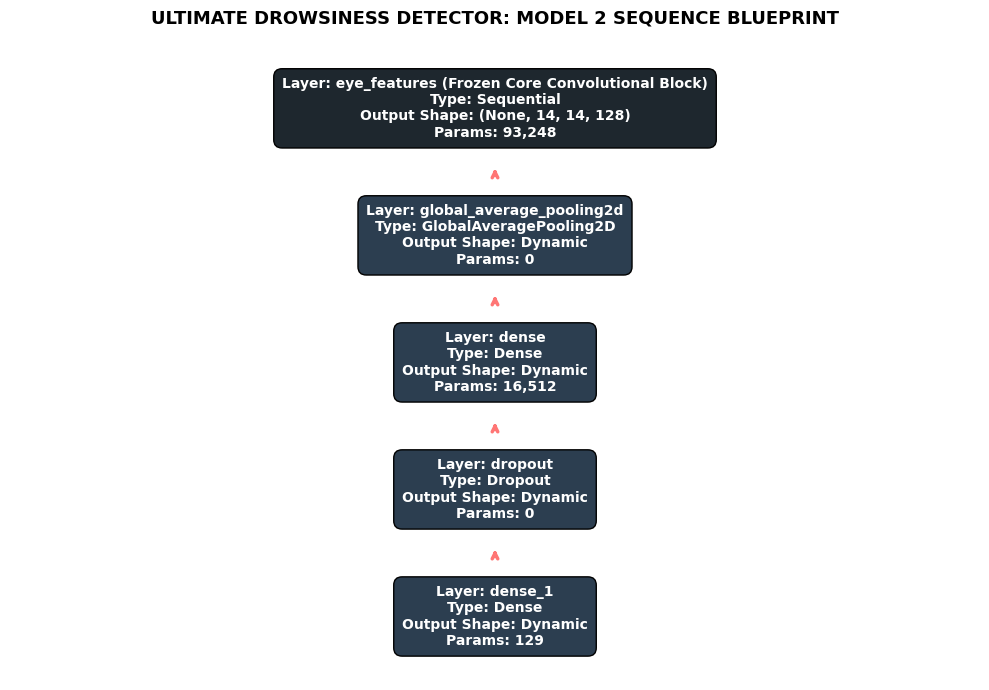

In [22]:
# 13. Visual summary
print("🎨 Drawing visual layer summary blueprint...")
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, len(active_model.layers) * 1.2 + 1))

for idx, layer in enumerate(reversed(active_model.layers)):
    try:
        plot_shape = layer.output_shape
    except AttributeError:
        plot_shape = "Dynamic"

    display_name = layer.name
    if layer.__class__.__name__ == 'Sequential':
        display_name = "eye_features (Frozen Core Convolutional Block)"

    ax.text(0.5, idx, f"Layer: {display_name}\nType: {layer.__class__.__name__}\nOutput Shape: {plot_shape}\nParams: {layer.count_params():,}",
            ha='center', va='center', color='white', fontweight='bold', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#1e272e' if layer.trainable==False else '#2c3e50', edgecolor='black'))

    if idx < len(active_model.layers) - 1:
        ax.annotate('', xy=(0.5, idx + 0.45), xytext=(0.5, idx + 0.55),
                    arrowprops=dict(arrowstyle="<-", color='#ff7675', lw=2.5))

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, len(active_model.layers) - 0.5)
ax.axis('off')
plt.title("ULTIMATE DROWSINESS DETECTOR: MODEL 2 SEQUENCE BLUEPRINT", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

img_buf = io.BytesIO()
plt.savefig(img_buf, format='png', dpi=150, bbox_inches='tight')
img_buf.seek(0)
encoded_visual_chart = base64.b64encode(img_buf.read()).decode('utf-8')
plt.show()
plt.close()

In [23]:
# 14. save to database
if model2_collection is not None:
    print("\n💾 Packaging blueprint payload and transmitting to MongoDB...")

    model2_document = {
        "timestamp": datetime.now(timezone.utc),
        "model_metadata": {
            "model_id": "model_2",
            "filename": "ultimate_drowsiness_system.h5",
            "framework": "TensorFlow Keras Sequential (Transfer Learning)"
        },
        "network_totals": {
            "total_top_level_layers": len(active_model.layers),
            "grand_total_parameters": int(active_model.count_params()),
            "total_individual_weights_count": int(total_weights_count),
            "total_individual_biases_count": int(total_biases_count)
        },
        "structural_blueprint_text": model_summary_text,
        "layer_by_layer_schema": layer_details,
        "visual_architecture_chart": encoded_visual_chart
    }

    try:
        write_receipt = model2_collection.insert_one(model2_document)
        print(f"🚀 Success! Model 2 configurations cataloged under Record ID: {write_receipt.inserted_id}")
    except Exception as db_err:
        print(f"❌ Failed to push document schema out to MongoDB: {db_err}")
else:
    print("\n❌ Storage bypassed: Database collection was unavailable.")

gc.collect()


💾 Packaging blueprint payload and transmitting to MongoDB...
🚀 Success! Model 2 configurations cataloged under Record ID: 6a1bd50f91ce51dc14773272


12826

In [24]:
# 15. Saving model
final_model.save('ultimate_drowsiness_system.h5')
print("\n🎉 Upgraded model saved successfully as ultimate_drowsiness_system.h5")


🎉 Upgraded model saved successfully as ultimate_drowsiness_system.h5
